In [1]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

import models.gnn_edges as gnn_edges

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load and split a graph dataset with atom-type and other atom specific (hybridization type, charge, H-count...) node features and bond-type edge features (and activities)

In [2]:

graphs_list = torch.load('../data_collection/graphs_with_edges.pt', weights_only=False)

graphs_train, graphs_val = train_test_split(
    graphs_list,
    test_size=0.10,
    random_state=42
)


train_loader = DataLoader(
    graphs_train, 
    batch_size=300,   
    shuffle=True
)

val_loader = DataLoader(
    graphs_val, 
    batch_size=300,   
    shuffle=True
)

device = torch.device("cpu")

Train a custom model with GatedEdgeConv layers (see ../models/gnn_edges.py) to predict activity values

In [4]:
epochs = 500
model = gnn_edges.GatedEdgeConv(128, 64, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) # early stopping applied

 24%|███████████████████████████████████████▍                                                                                                                           | 121/500 [09:46<30:38,  4.85s/it]


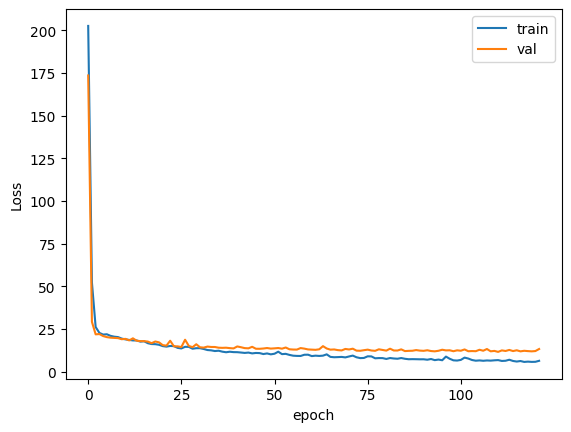

R² Train Score: 0.830
Train RMSE:     ±0.413
Train MAE:      ±0.323
R² Val Score: 0.601
Val RMSE:     ±0.631
Val MAE:      ±0.480


In [5]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with NNConv layers (see ../models/gnn_edges.py) to predict activity values

In [6]:
epochs = 500
model = gnn_edges.NNConv(128, 64, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) # early stopping applied

 32%|████████████████████████████████████████████████████▊                                                                                                              | 162/500 [21:24<44:40,  7.93s/it]


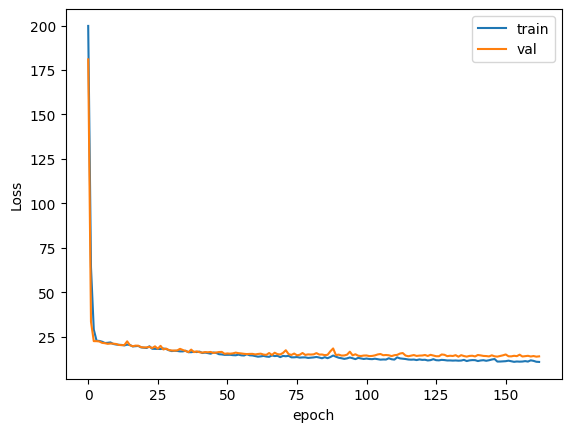

R² Train Score: 0.713
Train RMSE:     ±0.537
Train MAE:      ±0.385
R² Val Score: 0.557
Val RMSE:     ±0.664
Val MAE:      ±0.501


In [7]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GINE layers (see ../models/gnn_edges.py) to predict activity values

In [8]:
epochs = 500
model = gnn_edges.GINE(256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) #early stopping applied

 26%|███████████████████████████████████████████                                                                                                                        | 132/500 [04:28<12:27,  2.03s/it]


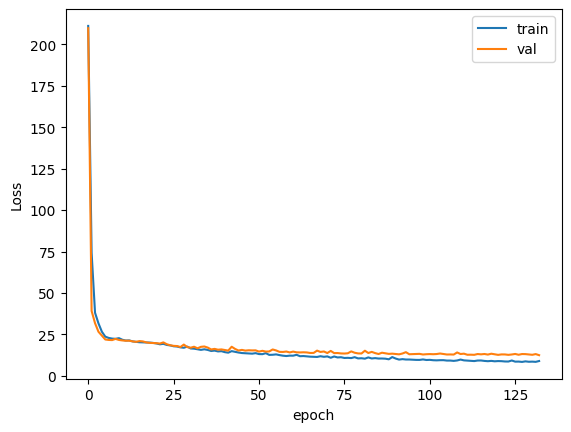

R² Train Score: 0.816
Train RMSE:     ±0.430
Train MAE:      ±0.297
R² Val Score: 0.628
Val RMSE:     ±0.608
Val MAE:      ±0.449


In [10]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train the Attention model (see ../models/gnn_edges.py) to predict activity values

In [11]:
epochs = 500
model = gnn_edges.Attention(128, 64, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs) #early stopping applied

 26%|██████████████████████████████████████████                                                                                                                         | 129/500 [10:49<31:09,  5.04s/it]


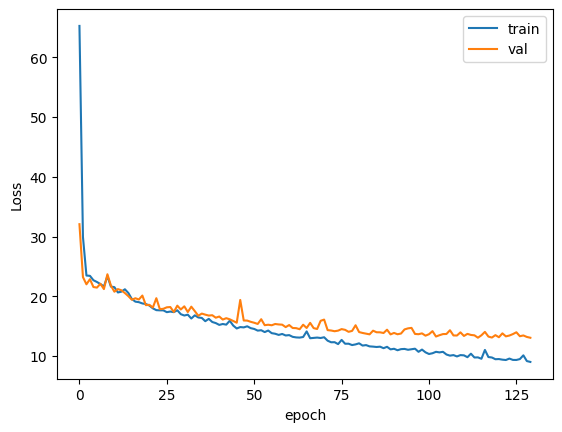

R² Train Score: 0.798
Train RMSE:     ±0.451
Train MAE:      ±0.314
R² Val Score: 0.598
Val RMSE:     ±0.633
Val MAE:      ±0.470


In [12]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, len(model.val_loss), 25))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)